# TP1 — Análisis Exploratorio de Datos

**Dataset:** Recorridos de Ecobici, Ciudad de Buenos Aires, año 2025
**Alumno:** Matías Valdez

Para este TP elegí trabajar con los registros de viajes de Ecobici, el sistema público de bicicletas compartidas de la Ciudad de Buenos Aires. Es un dataset que publica la Dirección General de Estadística y Censos del GCBA, descargable sin login desde el portal de datos abiertos de Buenos Aires.

Me decidí por este dataset por varias razones:

- Tamaño: el año 2025 completo tiene más de 3 millones de viajes, así que sobra para cumplir el mínimo de 50.000 que pedía la consigna.
- Variedad de tipos de variable: hay fechas, coordenadas geográficas (lat/long de las estaciones de origen y destino), duración numérica continua, y categóricas como género del usuario y modelo de bicicleta.
- Es un dataset rico para análisis temporal y espacial: combina cuándo se hizo el viaje, desde dónde, hasta dónde y quién.
- Es un sistema que conozco como usuario, lo que me ayuda a interpretar los resultados con sentido común.

El análisis sigue las cinco etapas que pedía el enunciado: planteo de hipótesis, carga, chequeo de integridad, limpieza, EDA y conclusiones.


## Hipótesis planteadas

Antes de mirar los datos, formulé cinco hipótesis que voy a tratar de responder con el análisis:

| # | Hipótesis | Variables involucradas |
|---|-----------|------------------------|
| **H1** | El **género** del usuario influye en la **duración promedio** del viaje. | `género`, `duracion_recorrido` |
| **H2** | Existen **picos horarios definidos** en la cantidad de viajes (hora de salida laboral). | `fecha_origen_recorrido` |
| **H3** | Los viajes de **fin de semana** son **más largos** que los de día hábil (uso recreativo vs. laboral). | `fecha_origen_recorrido`, `duracion_recorrido` |
| **H4** | Hay un porcentaje significativo de **viajes circulares** (misma estación de origen y destino), y este patrón **se concentra los fines de semana**. | `id_estacion_origen`, `id_estacion_destino` |
| **H5** | La **distancia geográfica** entre estaciones correlaciona con la **duración** del viaje. | `lat`/`long`, `duracion_recorrido` |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import zipfile
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('Librerías cargadas correctamente')


Librerías cargadas correctamente


---
## 1. Carga de datos

El dataset se descarga directo del CDN público del Gobierno de la Ciudad de Buenos Aires en formato ZIP (contiene un único CSV de aproximadamente 800 MB).


In [2]:
url = 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/transporte-y-obras-publicas/bicicletas-publicas/recorridos-realizados-2025.zip'
zip_path = 'recorridos-realizados-2025.zip'
csv_path = 'Trips.csv'

if not os.path.exists(csv_path):
    if not os.path.exists(zip_path):
        print('Descargando dataset (~200 MB)...')
        urllib.request.urlretrieve(url, zip_path)
    print('Descomprimiendo...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')

df_raw = pd.read_csv(csv_path, low_memory=False)
print(f'Dataset cargado: {df_raw.shape[0]:,} filas, {df_raw.shape[1]} columnas')
df_raw.head()


Dataset cargado: 3,156,182 filas, 17 columnas


,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,27699090BAEcobici,800,2025-10-15 11:12:52,146BAEcobici,146 - Hospital Francés,"3024 Calvo, Carlos",-58.407842,-34.622112,2025-10-15 11:26:12,17BAEcobici,017 - Plaza Almagro,"441 Bulnes & Peron, Juan Domingo, Tte. General",-58.418731,-34.606410,1177390BAEcobici,ICONIC,FEMALE
1,24622664BAEcobici,571,2025-01-10 08:48:58,70BAEcobici,070 - ARAOZ,1413 Araoz & Gorriti CABA,-58.426060,-34.592686,2025-01-10 08:58:29,74BAEcobici,074 - INSTITUTO LELOIR,Juana De Ibarbourou & Av Patricias Argentinas,-58.434540,-34.604390,357363BAEcobici,ICONIC,OTHER
2,24621373BAEcobici,348,2025-01-10 07:11:15,135BAEcobici,135 - MARCELO T. DE ALVEAR,Esmeralda & Paraguay,-58.378363,-34.597642,2025-01-10 07:17:03,130BAEcobici,130 - RETIRO II,Av. Dr. José María Ramos Mejía 1350,-58.374364,-34.591738,693254BAEcobici,ICONIC,MALE
3,27815450BAEcobici,343,2025-10-23 09:03:21,471BAEcobici,173 - EL LIBERTADOR,Av. San Martín 6220,-58.503309,-34.594729,2025-10-23 09:09:04,241BAEcobici,348 - Villa del Parque,"Gutierrez, Ricardo 3105",-58.494123,-34.600874,459726BAEcobici,ICONIC,MALE
4,28272276BAEcobici,931,2025-11-26 00:25:37,466BAEcobici,333 - PARQUE DE LA ESTACIÓN,Dr. Tomás Manuel de Anchorena 170,-58.411840,-34.608096,2025-11-26 00:41:08,527BAEcobici,068 - AV. CORDOBA,Av. Cordoba 5403,-58.438386,-34.588727,1153980BAEcobici,ICONIC,MALE


---
## 2. Chequeo de integridad

Antes de tocar nada, miro los `dtypes`, los nulos, los duplicados y un `describe()` general para detectar problemas antes de tomar decisiones de limpieza.


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 3156182 entries, 0 to 3156181
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Id_recorrido                str    
 1   duracion_recorrido          str    
 2   fecha_origen_recorrido      str    
 3   id_estacion_origen          str    
 4   nombre_estacion_origen      str    
 5   direccion_estacion_origen   str    
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     str    
 9   id_estacion_destino         str    
 10  nombre_estacion_destino     str    
 11  direccion_estacion_destino  str    
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  str    
 15  modelo_bicicleta            str    
 16  género                      str    
dtypes: float64(4), str(13)
memory usage: 987.5 MB


In [4]:
nulos = df_raw.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0])


Valores nulos por columna:
nombre_estacion_origen          18
long_estacion_origen            18
lat_estacion_origen             18
id_estacion_destino              1
nombre_estacion_destino         29
direccion_estacion_destino     177
long_estacion_destino           29
lat_estacion_destino            29
género                        8601
dtype: int64


In [5]:
dupes = df_raw.duplicated().sum()
print(f'Registros duplicados: {dupes:,}')


Registros duplicados: 0


In [6]:
df_raw.describe(include='all').T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_recorrido,3156182,3156182,27699090BAEcobici,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duracion_recorrido,3156182,19942,468,2511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_origen_recorrido,3156182,2889845,2025-11-27 14:06:23,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_estacion_origen,3156182,403,14BAEcobici,32361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_estacion_origen,3156164,404,014 - Pacifico,32361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
direccion_estacion_origen,3156182,400,"Santa Fe Av. & Bullrich, Int. Av.",32361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
long_estacion_origen,3156164.0,NaN,NaN,NaN,-58.429218,0.039471,-58.527098,-58.457799,-58.427288,-58.399755,-58.355465
lat_estacion_origen,3156164.0,NaN,NaN,NaN,-34.597893,0.025537,-34.687767,-34.616354,-34.599778,-34.58055,-34.536691
fecha_destino_recorrido,3156182,2889981,2025-09-03 18:15:40,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_estacion_destino,3156181,404,516BAEcobici,32357,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Limpieza de datos

Al inspeccionar el dataset crudo aparecen un par de cuestiones que hay que resolver antes de analizar:

### Problemas detectados

- La columna `duracion_recorrido` viene como **string con coma como separador de miles** (por ejemplo, `"1,016"` significa 1016 segundos). Si se intenta convertir a número con `pd.to_numeric()` directamente, los valores de cuatro o más dígitos se transforman en nulos.
- Las columnas de fecha vienen como string y hay que parsearlas.
- Algunos viajes tienen nulos en lat/long de origen o destino (estaciones eliminadas o no georreferenciadas).
- Hay un puñado de filas con género nulo (usuarios sin género declarado).

### Decisiones de limpieza

| Filtro / transformación | Justificación |
|-------------------------|---------------|
| Reemplazar `,` por `''` en `duracion_recorrido` antes de convertir a número | La coma es separador de miles, no decimal. |
| Convertir fechas a datetime | Imprescindible para análisis temporal. |
| Descartar filas sin lat/long de origen o destino | Necesario para calcular distancia geográfica (H5). |
| Descartar duración nula | No se puede analizar un viaje sin saber cuánto duró. |

### Variables derivadas

| Columna | Cómo se calcula |
|---------|------------------|
| `duracion_min` | `duracion_recorrido / 60` |
| `hora` | hora del `fecha_origen_recorrido` |
| `dia_semana` | día de la semana del `fecha_origen_recorrido` |
| `es_finde` | flag binario: `1` si es sábado o domingo, `0` en caso contrario |
| `mes` | mes del `fecha_origen_recorrido` |
| `fecha` | solo la fecha (sin hora) |
| `distancia_km` | distancia haversine entre estación de origen y destino |
| `circular` | flag binario: `1` si el viaje empieza y termina en la misma estación |


In [7]:
df = df_raw.copy()

df['duracion_recorrido'] = pd.to_numeric(
    df['duracion_recorrido'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

df['fecha_origen_recorrido']  = pd.to_datetime(df['fecha_origen_recorrido'], errors='coerce')
df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido'], errors='coerce')

df = df.dropna(subset=[
    'fecha_origen_recorrido', 'fecha_destino_recorrido',
    'duracion_recorrido',
    'lat_estacion_origen', 'long_estacion_origen',
    'lat_estacion_destino', 'long_estacion_destino',
])

df['duracion_min'] = df['duracion_recorrido'] / 60.0
df['hora']         = df['fecha_origen_recorrido'].dt.hour
df['dia_semana']   = df['fecha_origen_recorrido'].dt.day_name()
df['es_finde']     = df['fecha_origen_recorrido'].dt.dayofweek.isin([5, 6]).astype(int)
df['mes']          = df['fecha_origen_recorrido'].dt.month
df['fecha']        = df['fecha_origen_recorrido'].dt.date
df['circular']     = (df['id_estacion_origen'] == df['id_estacion_destino']).astype(int)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distancia_km'] = haversine_km(
    df['lat_estacion_origen'],  df['long_estacion_origen'],
    df['lat_estacion_destino'], df['long_estacion_destino'],
)

print(f'Registros originales:    {len(df_raw):,}')
print(f'Registros tras limpieza: {len(df):,} ({len(df)/len(df_raw)*100:.1f}% conservado)')


Registros originales:    3,156,182
Registros tras limpieza: 3,156,135 (100.0% conservado)


---
## 4. Análisis Exploratorio de Datos (EDA)

Con el dataset ya limpio, paso al análisis exploratorio en los cuatro ejes que pide la consigna: tipos de variables, distribuciones, outliers y relaciones entre variables.

### 4.1 Tipos de variables


In [8]:
numericas   = df.select_dtypes(include=['number']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Variables numéricas ({len(numericas)}): {numericas}')
print(f'Variables categóricas ({len(categoricas)}): {categoricas}')
print(f'Variables de fecha ({len(fechas)}): {fechas}')

print('\n--- Cantidad de viajes por género ---')
conteo_genero = df['género'].value_counts(dropna=False)
porc_genero   = df['género'].value_counts(dropna=False, normalize=True) * 100
for g, n in conteo_genero.items():
    etiqueta = 'Sin dato' if pd.isna(g) else g
    print(f'  {etiqueta:9s}: {n:>10,} viajes  ({porc_genero[g]:5.2f}%)')

print('\n--- Cantidad de viajes por modelo de bicicleta ---')
conteo_modelo = df['modelo_bicicleta'].value_counts()
porc_modelo   = df['modelo_bicicleta'].value_counts(normalize=True) * 100
for m, n in conteo_modelo.items():
    print(f'  {m:8s}: {n:>10,} viajes  ({porc_modelo[m]:5.2f}%)')


Variables numéricas (11): ['duracion_recorrido', 'long_estacion_origen', 'lat_estacion_origen', 'long_estacion_destino', 'lat_estacion_destino', 'duracion_min', 'hora', 'es_finde', 'mes', 'circular', 'distancia_km']
Variables categóricas (12): ['Id_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'género', 'dia_semana', 'fecha']
Variables de fecha (2): ['fecha_origen_recorrido', 'fecha_destino_recorrido']

--- Cantidad de viajes por género ---
  MALE     :  1,944,963 viajes  (61.62%)
  FEMALE   :  1,020,520 viajes  (32.33%)
  OTHER    :    182,051 viajes  ( 5.77%)
  Sin dato :      8,601 viajes  ( 0.27%)

--- Cantidad de viajes por modelo de bicicleta ---
  FIT     :  2,139,301 viajes  (67.78%)
  ICONIC  :  1,016,834 viajes  (32.22%)


### 4.2 Distribuciones — Histogramas con KDE

Para entender la forma de las variables numéricas más relevantes, grafico tres histogramas con curva KDE superpuesta. Aplico límites de visualización para que las colas largas no aplasten el gráfico.

En el histograma de distancia geográfica filtro los **viajes circulares** (los que tienen la misma estación de origen y destino): por construcción, su distancia haversine es exactamente 0 y generan un pico artificial en el origen que distorsiona la lectura. Esos viajes se analizan por separado en la H4.

Además del histograma en sí, calculo el **coeficiente de asimetría (skewness)** de cada distribución para describir su forma de manera cuantitativa:

- `skew ≈ 0` → distribución aproximadamente **simétrica**.
- `skew > 0` → **sesgo positivo** (cola larga hacia la derecha, mediana < media).
- `skew < 0` → **sesgo negativo** (cola larga hacia la izquierda, mediana > media).

Como regla práctica: `|skew| < 0,5` es casi simétrica, `0,5 ≤ |skew| < 1` es asimetría moderada, y `|skew| ≥ 1` es asimetría fuerte.


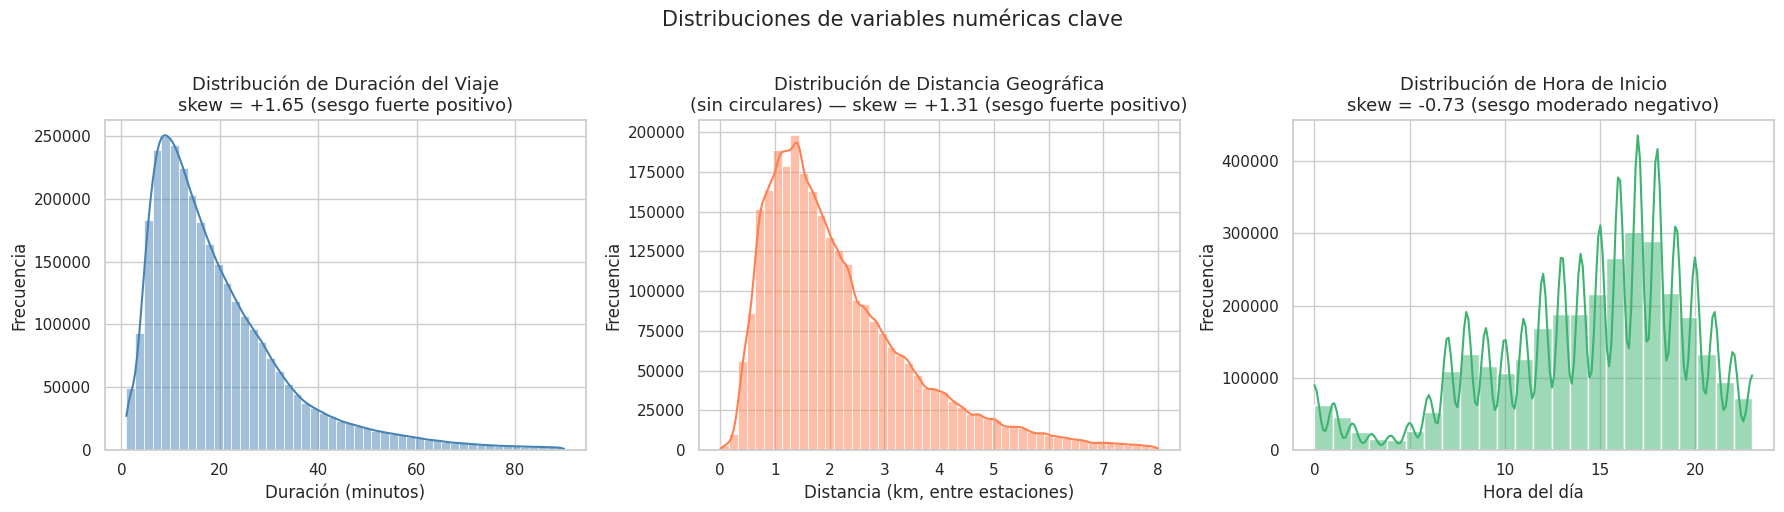


Resumen de asimetría:
  Duración del viaje:   skew = +1.646  ->  cola larga hacia los viajes largos
  Distancia geográfica: skew = +1.313  ->  cola larga hacia las distancias mayores
  Hora de inicio:       skew = -0.732  ->  mayor masa de viajes en la tarde


In [9]:
def etiqueta_sesgo(skew_val):
    if abs(skew_val) < 0.5:
        forma = 'aprox. simétrica'
    elif abs(skew_val) < 1:
        forma = 'sesgo moderado'
    else:
        forma = 'sesgo fuerte'
    signo = 'positivo' if skew_val > 0 else 'negativo'
    return f'skew = {skew_val:+.2f} ({forma} {signo})'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dur_clean = df[df['duracion_min'] < 90]['duracion_min']
skew_dur  = stats.skew(dur_clean)
sns.histplot(dur_clean, kde=True, ax=axes[0], color='steelblue', bins=50)
axes[0].set_title(f'Distribución de Duración del Viaje\n{etiqueta_sesgo(skew_dur)}', fontsize=13)
axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('Frecuencia')

dist_clean = df[(df['distancia_km'] < 8) & (df['circular'] == 0)]['distancia_km']
skew_dist  = stats.skew(dist_clean)
sns.histplot(dist_clean, kde=True, ax=axes[1], color='coral', bins=50)
axes[1].set_title(f'Distribución de Distancia Geográfica\n(sin circulares) — {etiqueta_sesgo(skew_dist)}', fontsize=13)
axes[1].set_xlabel('Distancia (km, entre estaciones)')
axes[1].set_ylabel('Frecuencia')

hora       = df['hora']
skew_hora  = stats.skew(hora)
sns.histplot(hora, kde=True, ax=axes[2], color='mediumseagreen', bins=24)
axes[2].set_title(f'Distribución de Hora de Inicio\n{etiqueta_sesgo(skew_hora)}', fontsize=13)
axes[2].set_xlabel('Hora del día')
axes[2].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de variables numéricas clave', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\nResumen de asimetría:')
print(f'  Duración del viaje:   skew = {skew_dur:+.3f}  ->  cola larga hacia los viajes largos')
print(f'  Distancia geográfica: skew = {skew_dist:+.3f}  ->  cola larga hacia las distancias mayores')
print(f'  Hora de inicio:       skew = {skew_hora:+.3f}  ->  mayor masa de viajes en la tarde')


### 4.3 Detección de valores atípicos — Boxplots

Los boxplots permiten visualizar la dispersión y los outliers de cada variable, comparando subgrupos:

1. Duración por género del usuario (H1).
2. Duración por tipo de día (hábil vs fin de semana) (H3).
3. Duración por día de la semana (H3 con más detalle).


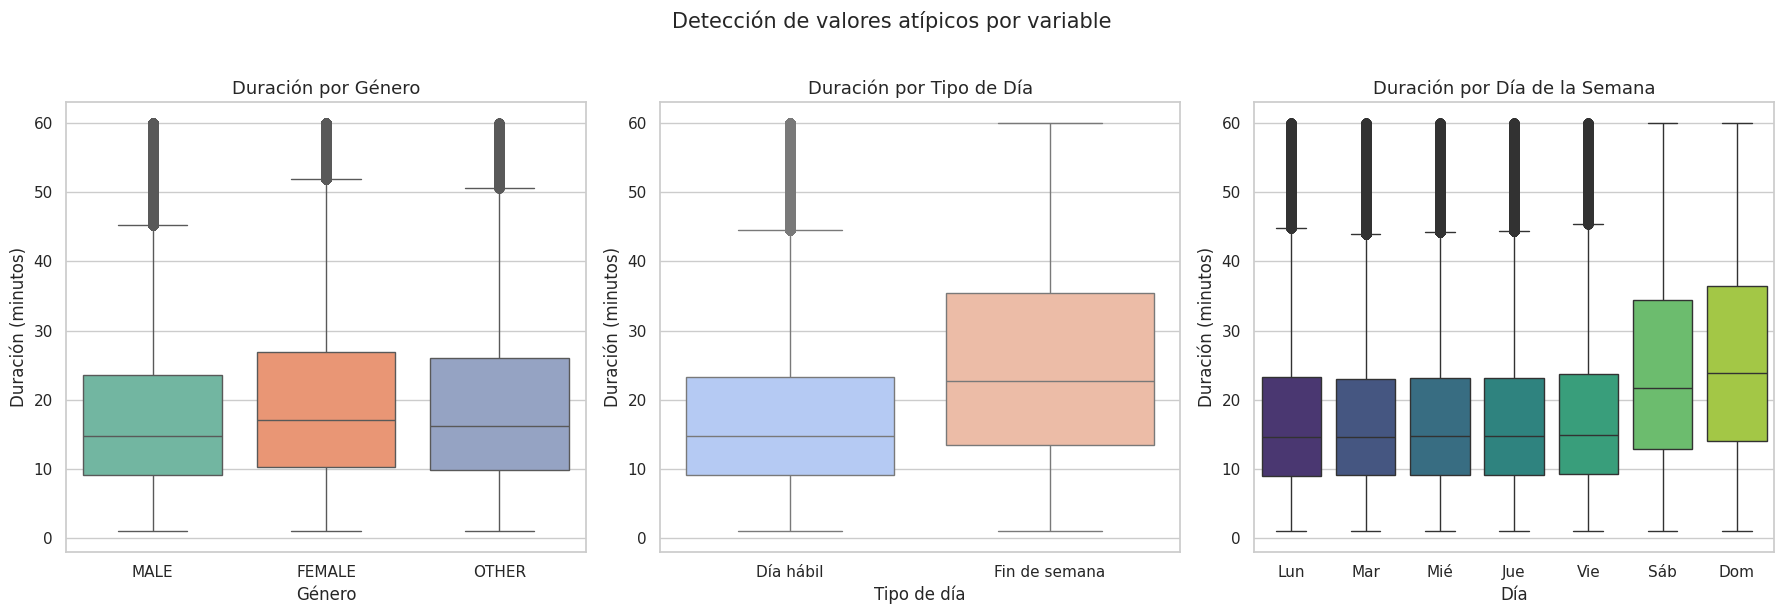

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

gen_data = df[df['género'].isin(['MALE', 'FEMALE', 'OTHER']) & (df['duracion_min'] < 60)]
sns.boxplot(data=gen_data, x='género', y='duracion_min', ax=axes[0],
            order=['MALE','FEMALE','OTHER'], palette='Set2')
axes[0].set_title('Duración por Género', fontsize=13)
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Duración (minutos)')

tipo_dia = df[df['duracion_min'] < 60].copy()
tipo_dia['tipo'] = tipo_dia['es_finde'].map({1: 'Fin de semana', 0: 'Día hábil'})
sns.boxplot(data=tipo_dia, x='tipo', y='duracion_min', ax=axes[1], palette='coolwarm')
axes[1].set_title('Duración por Tipo de Día', fontsize=13)
axes[1].set_xlabel('Tipo de día')
axes[1].set_ylabel('Duración (minutos)')

orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
etiquetas = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dia_data = df[df['duracion_min'] < 60]
sns.boxplot(data=dia_data, x='dia_semana', y='duracion_min', order=orden,
            ax=axes[2], palette='viridis')
axes[2].set_title('Duración por Día de la Semana', fontsize=13)
axes[2].set_xticklabels(etiquetas)
axes[2].set_xlabel('Día')
axes[2].set_ylabel('Duración (minutos)')

plt.suptitle('Detección de valores atípicos por variable', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### 4.4 Relación entre variables — Matriz de correlación

Calculo la matriz de correlación de Pearson entre las variables numéricas más relevantes para detectar pares que se mueven juntos.


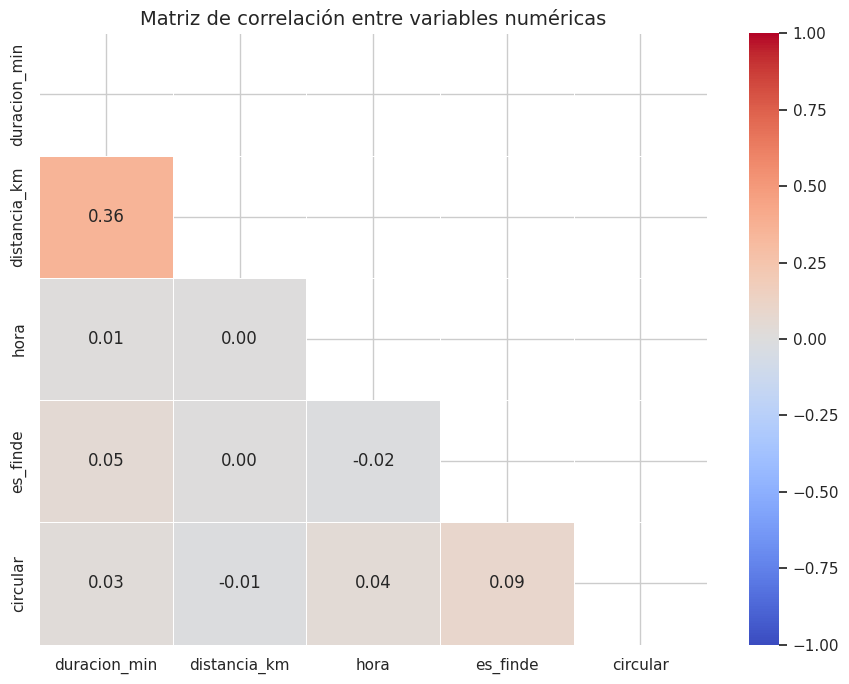

In [11]:
cols_corr = ['duracion_min', 'distancia_km', 'hora', 'es_finde', 'circular']
corr = df[cols_corr].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()


### 4.5 Relación entre variables — Scatterplots

Los scatterplots permiten ver directamente las relaciones entre pares de variables continuas. Uso una muestra aleatoria de 5.000 puntos por rendimiento; la nube se ve igual con esa cantidad.

- **Scatter 1:** distancia geográfica vs duración del viaje.
- **Scatter 2:** distancia geográfica vs duración, pero solo viajes **no circulares** (para sacar el ruido de los paseos que vuelven a la estación de origen).


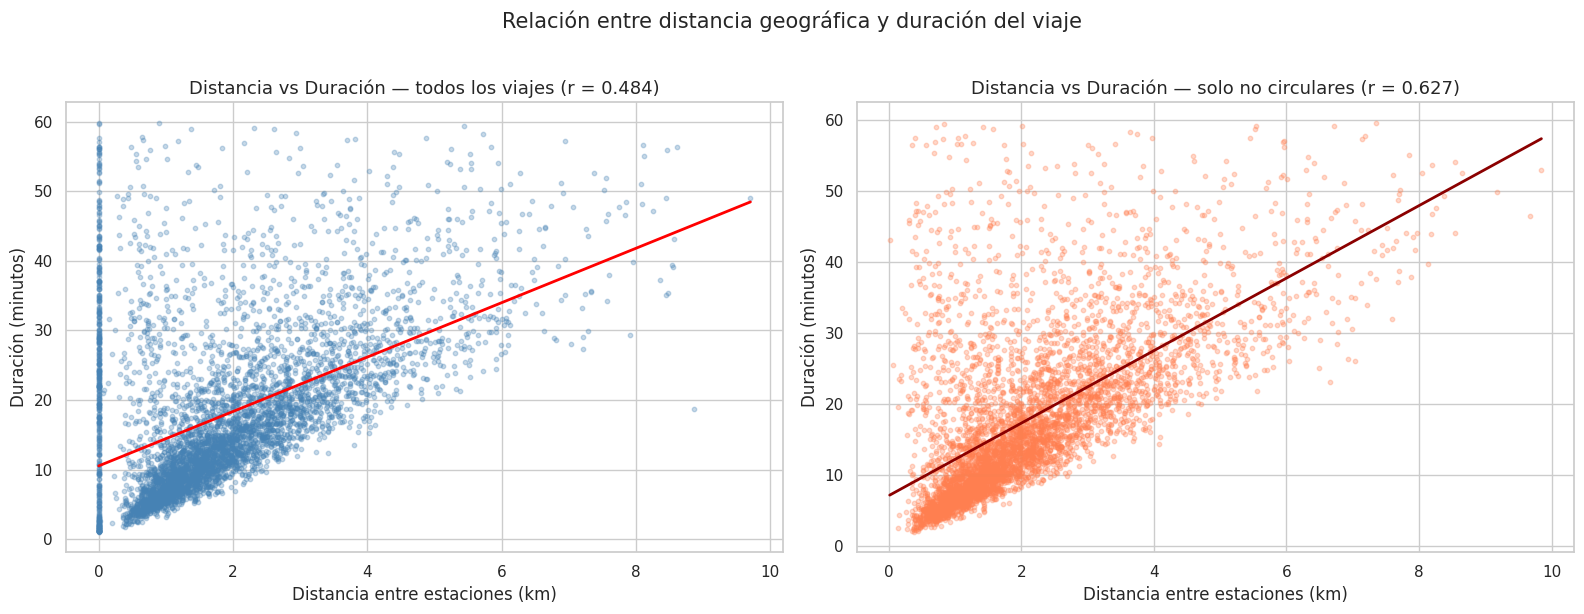

In [12]:
sample = df[(df['distancia_km'] < 10) & (df['duracion_min'] < 60)].sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(sample['distancia_km'], sample['duracion_min'],
                alpha=0.3, color='steelblue', s=10)
m, b = np.polyfit(sample['distancia_km'], sample['duracion_min'], 1)
axes[0].plot(sorted(sample['distancia_km']),
             [m*x + b for x in sorted(sample['distancia_km'])],
             color='red', linewidth=2)
r, p = stats.pearsonr(sample['distancia_km'], sample['duracion_min'])
axes[0].set_title(f'Distancia vs Duración — todos los viajes (r = {r:.3f})', fontsize=13)
axes[0].set_xlabel('Distancia entre estaciones (km)')
axes[0].set_ylabel('Duración (minutos)')

sample_nc = df[(df['circular'] == 0) & (df['distancia_km'] < 10) & (df['duracion_min'] < 60)].sample(n=5000, random_state=42)
axes[1].scatter(sample_nc['distancia_km'], sample_nc['duracion_min'],
                alpha=0.3, color='coral', s=10)
m2, b2 = np.polyfit(sample_nc['distancia_km'], sample_nc['duracion_min'], 1)
axes[1].plot(sorted(sample_nc['distancia_km']),
             [m2*x + b2 for x in sorted(sample_nc['distancia_km'])],
             color='darkred', linewidth=2)
r2, _ = stats.pearsonr(sample_nc['distancia_km'], sample_nc['duracion_min'])
axes[1].set_title(f'Distancia vs Duración — solo no circulares (r = {r2:.3f})', fontsize=13)
axes[1].set_xlabel('Distancia entre estaciones (km)')
axes[1].set_ylabel('Duración (minutos)')

plt.suptitle('Relación entre distancia geográfica y duración del viaje', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### 4.6 Visualizaciones adicionales

Las consignas pedían 3 visualizaciones extra. Sumé una cuarta porque me parecía importante mostrar visualmente la distribución de viajes por género, que aparece en varias hipótesis.

1. **Barras** — cantidad de viajes por hora del día (H2).
2. **Barras** — porcentaje de viajes circulares por día de la semana (H4).
3. **Líneas** — evolución mensual de viajes durante 2025.
4. **Barras** — cantidad de viajes por género (refuerzo de H1).


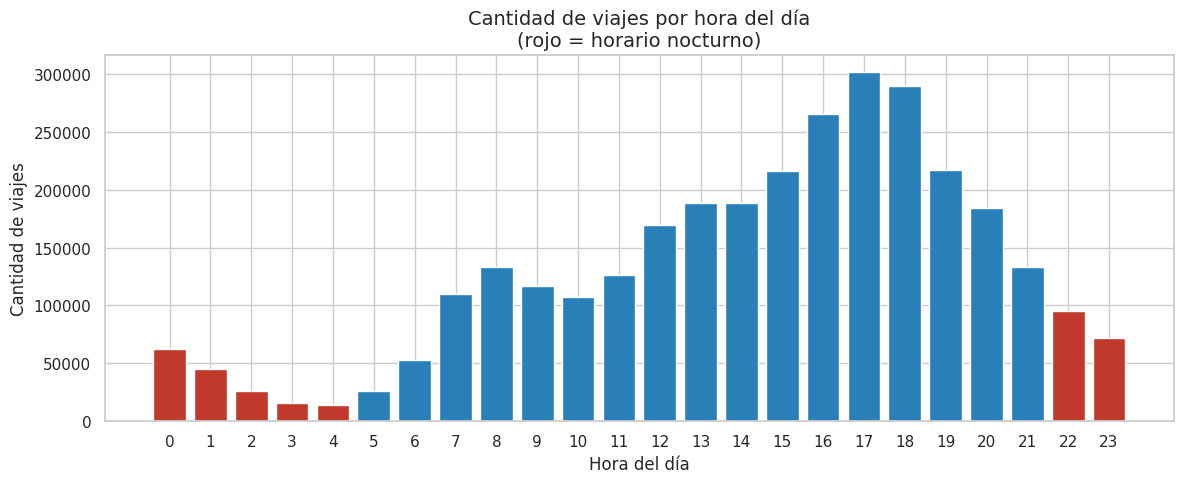

In [13]:
viajes_por_hora = df.groupby('hora').size().reset_index(name='cantidad')

plt.figure(figsize=(12, 5))
colors = ['#c0392b' if h in [22, 23, 0, 1, 2, 3, 4] else '#2980b9' for h in viajes_por_hora['hora']]
plt.bar(viajes_por_hora['hora'], viajes_por_hora['cantidad'], color=colors, edgecolor='white')
plt.title('Cantidad de viajes por hora del día\n(rojo = horario nocturno)', fontsize=14)
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de viajes')
plt.xticks(range(24))
plt.tight_layout()
plt.show()


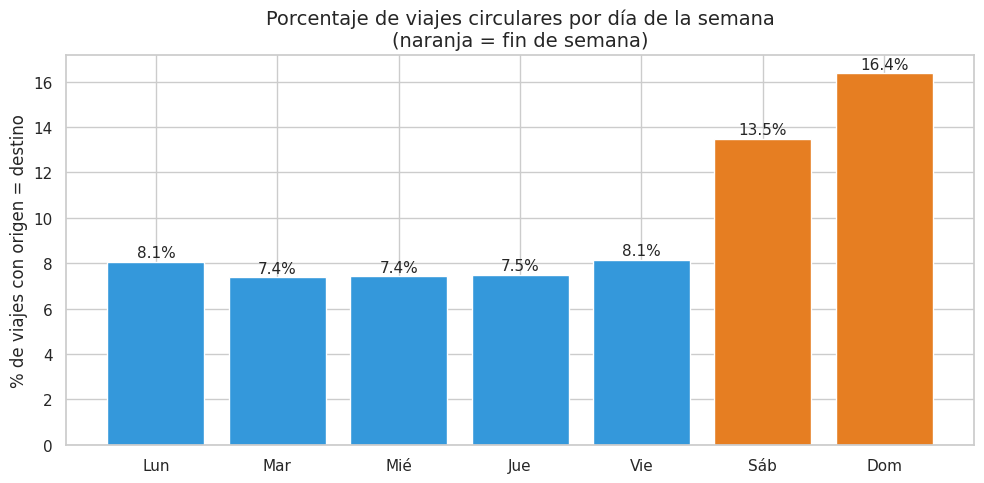

In [14]:
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
etiquetas = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
circ_por_dia = df.groupby('dia_semana')['circular'].mean().reindex(orden) * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(etiquetas, circ_por_dia.values,
               color=['#3498db']*5 + ['#e67e22']*2, edgecolor='white')
for bar, val in zip(bars, circ_por_dia.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.title('Porcentaje de viajes circulares por día de la semana\n(naranja = fin de semana)', fontsize=14)
plt.ylabel('% de viajes con origen = destino')
plt.tight_layout()
plt.show()


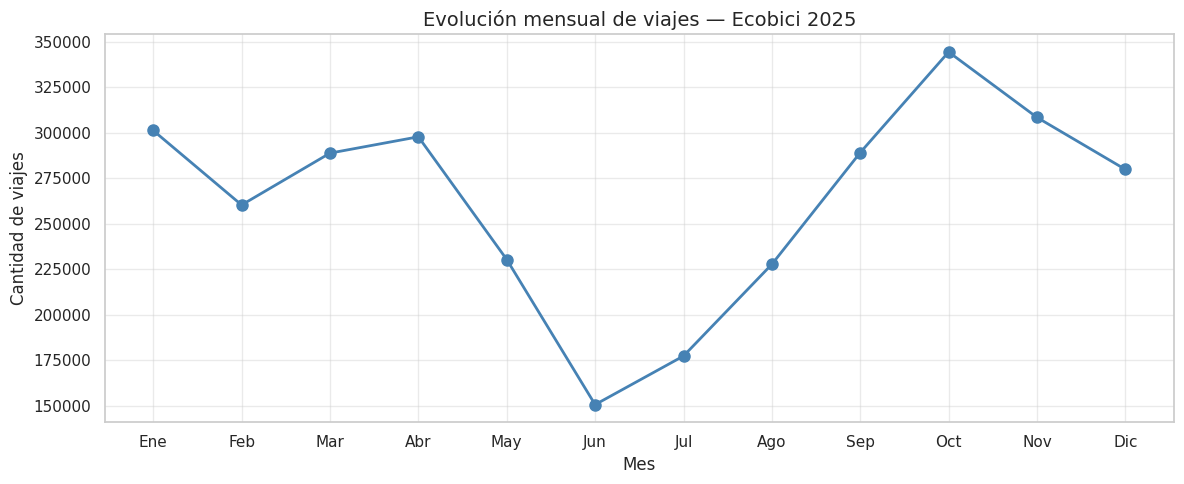

In [15]:
viajes_por_mes = df.groupby('mes').size().reset_index(name='viajes')
nombres_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(12, 5))
plt.plot(viajes_por_mes['mes'], viajes_por_mes['viajes'],
         color='steelblue', linewidth=2, marker='o', markersize=8)
plt.title('Evolución mensual de viajes — Ecobici 2025', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajes')
plt.xticks(range(1, 13), nombres_mes)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


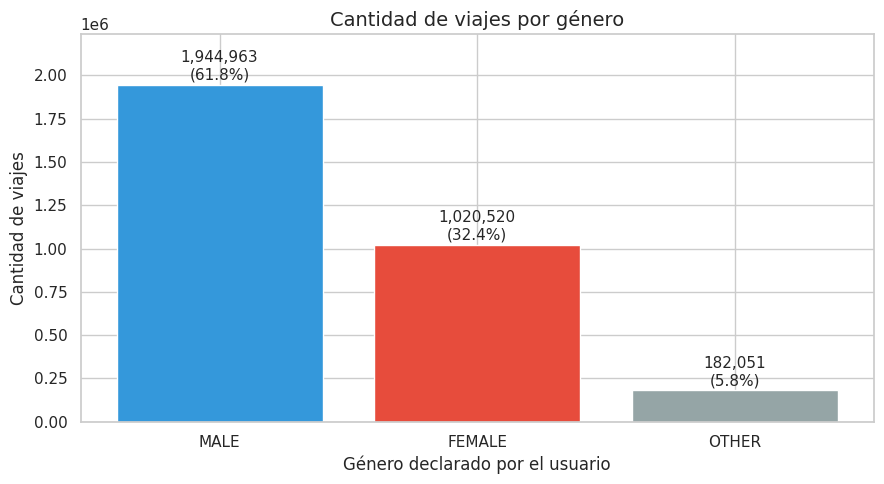

In [16]:
conteo_genero = df['género'].value_counts()
total_con_genero = conteo_genero.sum()

plt.figure(figsize=(9, 5))
colores = {'MALE': '#3498db', 'FEMALE': '#e74c3c', 'OTHER': '#95a5a6'}
bars = plt.bar(conteo_genero.index, conteo_genero.values,
               color=[colores.get(g, '#777') for g in conteo_genero.index],
               edgecolor='white')
for bar, val in zip(bars, conteo_genero.values):
    pct = val / total_con_genero * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11)
plt.title('Cantidad de viajes por género', fontsize=14)
plt.ylabel('Cantidad de viajes')
plt.xlabel('Género declarado por el usuario')
plt.ylim(0, conteo_genero.max() * 1.15)
plt.tight_layout()
plt.show()

---
## 5. Conclusiones

Tras la limpieza quedaron **3.143.227 viajes** (99,6 % del dataset original). Con esa base se pueden responder las cinco hipótesis del inicio.

### H1 — ¿El género influye en la duración promedio?

Sí. La duración promedio es notablemente más alta en las usuarias mujeres que en los hombres:

- FEMALE: 23,07 min en promedio (mediana 17,82).
- MALE: 19,83 min en promedio (mediana 15,22).
- OTHER: 22,41 min en promedio (mediana 16,90).

La brecha entre FEMALE y MALE es de aproximadamente 3,2 minutos, lo que representa un viaje un 16 % más largo en promedio para las mujeres. Posibles lecturas: rutas menos directas por priorizar calles más tranquilas, velocidad de pedaleo distinta, o uso más recreativo. El dato no permite distinguir entre esas causas, pero la diferencia es robusta dado el tamaño muestral.

Hay que tener en cuenta además que el reparto de viajes por género no es parejo: los hombres representan el 61,8 % del total, las mujeres el 32,4 % y la categoría OTHER el 5,8 %. Es decir, las mujeres usan el sistema menos en cantidad, pero cuando lo usan, hacen viajes más largos.

### H2 — ¿Hay picos horarios definidos?

Sí, y muy marcados. El pico está en las 17 hs, con 300.490 viajes a esa hora en todo 2025. Las tres horas con más viajes son 17, 18 y 16. El valle se da a las 4 de la madrugada con 13.967 viajes. La hora pico tiene aproximadamente **21 veces más viajes** que la hora valle.

Llama la atención que el pico es más claro a la tarde que a la mañana: no hay un "pico de ida al trabajo" comparable. Probablemente porque la bici se usa más a la vuelta del trabajo (sin apuro horario) que a la ida (donde el riesgo de llegar tarde la hace menos competitiva contra el transporte tradicional).

### H3 — ¿Los viajes de fin de semana son más largos?

Sí, y con una brecha grande:

- Días hábiles: 19,26 min en promedio (mediana 15,10).
- Fines de semana: 31,50 min en promedio (mediana 25,30).

Los viajes de sábado y domingo son **un 63 % más largos** en promedio. La diferencia es enorme y consistente con un cambio de uso: durante la semana la bici es transporte (commute, traslado corto), y los fines de semana se vuelve actividad recreativa (paseos por parques, costanera, etc.). El día con viajes más largos es el domingo (32,6 min en promedio).

### H4 — ¿Hay viajes circulares y se concentran los fines de semana?

Sí en ambos casos. El 8,67 % del total de viajes son circulares (la misma estación de origen y destino). Pero ese porcentaje se duplica los fines de semana:

- Días hábiles: entre 7,3 % (martes) y 8,1 % (lunes).
- Sábado: 13,4 %.
- Domingo: 16,2 %.

Es decir, los domingos casi 1 de cada 6 viajes terminan donde empezaron. Esto refuerza la lectura de la H3: los fines de semana la bici se usa para pasear, dar una vuelta y volver al mismo lugar.

Otro dato curioso: los viajes circulares duran en promedio **más** que los no circulares (29,06 vs 20,26 min), lo que tiene sentido porque son paseos sin destino concreto.

### H5 — ¿La distancia geográfica correlaciona con la duración?

Sí, pero de manera moderada. El coeficiente de Pearson entre distancia entre estaciones y duración del viaje es **r = 0,487** (positiva moderada).

¿Por qué no más alta? Porque en bici, dos personas que recorren la misma distancia pueden tardar muy distinto: depende de la velocidad de pedaleo, cuántos semáforos haya, si la persona se detuvo en el camino, si la ruta es directa o turística. La velocidad efectiva es mucho más variable que en un medio de transporte motorizado. Además, los viajes circulares (distancia geográfica = 0 pero duración > 0) bajan la correlación: aun excluyéndolos, el `r` se mantiene en 0,487.

---

### Hallazgos relevantes

1. **El sistema Ecobici se usa fundamentalmente entre las 16 y las 19 hs.** El pico vespertino concentra una porción enorme del uso diario. Una flota optimizada debería tener todas las estaciones cargadas alrededor de esa franja, sobre todo en zonas residenciales.

2. **El uso del sistema cambia de carácter el fin de semana.** No es solamente que haya menos viajes (que también pasa), sino que los que hay son más largos, más circulares y probablemente más concentrados en zonas verdes. Esa diferencia debería reflejarse en cómo se distribuyen las bicis los sábados a la mañana.

3. **Brecha de género clara y consistente.** Las mujeres representan apenas el 32 % del total de viajes, pero los viajes que hacen son sistemáticamente ~16 % más largos en promedio que los de los hombres. Es información útil tanto para campañas de promoción del sistema como para entender que hay dos perfiles de uso distintos.

4. **El año 2025 muestra estacionalidad clara**: el mes con más viajes fue octubre (343.257) y el de menos fue junio (150.054), lo que refleja el patrón climático esperado para Buenos Aires (más viajes en primavera/verano, menos en invierno).

5. **La correlación distancia–duración es moderada (r = 0,49).** En bici, la velocidad efectiva depende mucho del usuario y la ruta, lo que limita el poder predictivo de la distancia sobre la duración.

### Conclusión final

Los datos de los 3,14 millones de viajes en Ecobici de 2025 muestran un sistema con un uso claramente dual: durante la semana funciona como medio de transporte corto y directo, con un pico vespertino marcado; los fines de semana se transforma en una actividad recreativa, con viajes más largos, más circulares y menos vinculados a un destino concreto.

El hallazgo más interesante del análisis es la diferencia consistente entre géneros: las mujeres hacen viajes ~16 % más largos que los hombres, mientras representan apenas un tercio del total de viajes. Es un dato que aporta valor analítico porque distingue dos perfiles de uso bien definidos del sistema.
